In [82]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


## 1. Load dữ liệu

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Khám phá dữ liệu

In [84]:
# Xem tổng quan: kiểu dữ liệu, missing values
train.info()
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

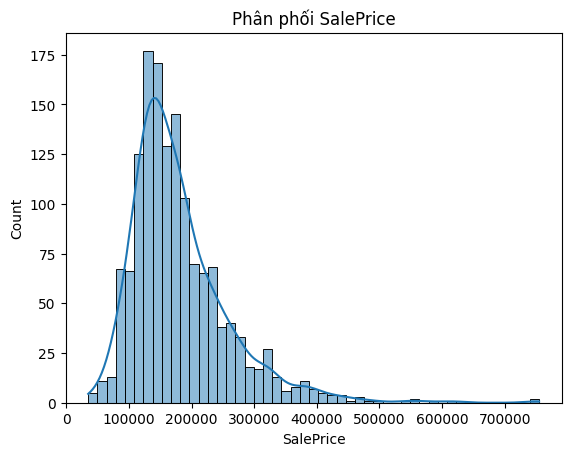

Skewness: 1.8828757597682129


In [85]:
# Phân phối biến mục tiêu SalePrice — thường bị lệch phải (right-skewed)
sns.histplot(train['SalePrice'], kde=True)
plt.title('Phân phối SalePrice')
plt.show()

print("Skewness:", train['SalePrice'].skew())

In [86]:
# Correlation với SalePrice — xem biến nào ảnh hưởng mạnh nhất
corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


## 3. Xử lý outlier

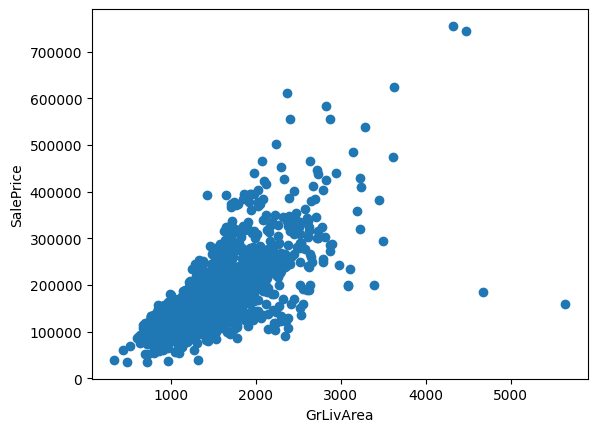

In [87]:
# Trực quan hóa để thấy outlier
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

# Loại bỏ outlier: GrLivArea > 4000 nhưng SalePrice thấp
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

## 4. Gộp train và test

In [88]:
train_id = train['Id']
test_id = test['Id']
y = np.log1p(train['SalePrice'])  # log-transform để giảm skew

train_features = train.drop(['Id', 'SalePrice'], axis=1)
test_features = test.drop(['Id'], axis=1)

all_data = pd.concat([train_features, test_features], axis=0, ignore_index=True)
print(all_data.shape)

(2917, 79)


## 5. Xử lý missing values

In [89]:
# Nhóm 1: NaN nghĩa là "không có" -> điền "None"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# Nhóm 2: NaN nghĩa là 0 (số lượng/diện tích = 0 vì không có hạng mục đó)
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# Nhóm 3: LotFrontage -> điền theo median của từng Neighborhood
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Nhóm 4: các cột categorical còn thiếu ít -> điền mode (giá trị phổ biến nhất)
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
             'Exterior2nd', 'SaleType', 'Functional', 'Utilities']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print("Còn lại missing:", all_data.isnull().sum().sum())

Còn lại missing: 0


# Feature engineering

## 6. Feature engineering

In [90]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                          all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

## 7. Encode biến categorical

In [91]:
# One-Hot Encoding cho các biến phân loại (nominal)
all_data = pd.get_dummies(all_data, drop_first=True)
print(all_data.shape)

# Tách lại thành train / test
X = all_data.iloc[:len(y), :]
X_test = all_data.iloc[len(y):, :]

(2917, 262)


## 8. Modeling

In [92]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model, X_data):
    scores = np.sqrt(-cross_val_score(model, X_data, y, scoring='neg_mean_squared_error', cv=kf))
    return scores.mean()
    
models = {
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.001),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3, random_state=42)
}

for name, model in models.items():
    score = rmse_cv(model, X_scaled)
    print(f"{name}: RMSE (log scale) = {score:.4f}")



Ridge: RMSE (log scale) = 0.1259
Lasso: RMSE (log scale) = 0.1191
RandomForest: RMSE (log scale) = 0.1373
XGBoost: RMSE (log scale) = 0.1251


## 9. Chọn best model và dự đoán

In [93]:
best_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3, random_state=42)
best_model.fit(X, y)

preds_log = best_model.predict(X_test)
preds = np.expm1(preds_log)  # đảo ngược log1p lúc đầu

submission = pd.DataFrame({'Id': test_id, 'SalePrice': preds})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,122831.203125
1,1462,163032.171875
2,1463,183926.390625
3,1464,193605.875000
4,1465,186139.546875
